In [3]:
!pip install earthengine-api geemap -q

import ee
import geemap
import numpy as np
import pandas as pd
from datetime import datetime
import ee
import geemap
import numpy as np
import pandas as pd
import rasterio
from rasterio.transform import from_bounds
import os, gc
from tqdm import tqdm

ee.Authenticate()
ee.Initialize(project='ee-engine-asmaoui')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 136.3 MB/s eta 0:00:00


In [14]:
# # # ── CELL 3: GEE Export → GeoTIFFs (one per year) ─────────────
# import ee
# import geemap

# ee.Authenticate()
# ee.Initialize(project='ee-engine-asmaoui')

# morocco = ee.FeatureCollection('USDOS/LSIB_SIMPLE/2017') \
#             .filter(ee.Filter.inList('country_na', ['Morocco', 'Western Sahara']))
# region  = morocco.geometry()

# VARIABLES = [
#     # 'temperature_2m',
#     'temperature_2m_max',
#     'temperature_2m_min',
#     'u_component_of_wind_10m',
#     'v_component_of_wind_10m',
#     'dewpoint_temperature_2m',
#     'soil_temperature_level_1',
#     'surface_solar_radiation_downwards_sum', # rayonnement
#     'surface_pressure',
#     'volumetric_soil_water_layer_1', #humidité du sol
# ]

# def export_year_tif(year):
#     col = ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR') \
#         .filterDate(f'{year}-01-01', f'{year}-12-31') \
#         .filter(ee.Filter.calendarRange(1, 12, 'month')) \
#         .select(VARIABLES) \
#         .map(lambda img: img.clip(region))

#     # Stack all days as bands
#     stacked = col.toBands()

#     task = ee.batch.Export.image.toDrive(
#         image=stacked,
#         description=f'ERA5_Morocco_{year}',
#         folder='ERA5_Morocco_GeoTIFF_All',
#         fileNamePrefix=f'ERA5_Morocco_{year}',
#         scale=11132,
#         region=region,
#         crs='EPSG:4326',
#         fileFormat='GeoTIFF',
#         maxPixels=1e13
#     )
#     task.start()
#     print(f'  ↑ {year} export started')

# print("🚀 Exporting 1980–2025...")
# for year in range(2025, 2026):
#     export_year_tif(year)
# print("✅ All tasks submitted — wait for Drive sync")

🚀 Exporting 1980–2025...
  ↑ 2025 export started
✅ All tasks submitted — wait for Drive sync


In [3]:
# ── 2. Define Morocco boundary & period ───────────────────────────
morocco = ee.FeatureCollection('USDOS/LSIB_SIMPLE/2017') \
            .filter(ee.Filter.inList('country_na', ['Morocco', 'Western Sahara']))


region = morocco.geometry()

# April to September (adjust year as needed)
start = '1980-04-01'
end   = '2025-09-30'


In [4]:
# ── 3. Select variables ────────────────────────────────────────────
VARIABLES = [
    'temperature_2m_max',
    'temperature_2m_min',
    'u_component_of_wind_10m',
    'v_component_of_wind_10m',
    'surface_solar_radiation_downwards_sum', # rayonnement
    'dewpoint_temperature_2m',
    'surface_pressure',
    'volumetric_soil_water_layer_1', #humidité du sol
    # humidity

]

In [5]:
# ── 4. Load ERA5-Land Daily & clip to Morocco ────────────────────
collection = ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR') \
    .filterDate(start, end) \
    .select(VARIABLES) \
    .map(lambda img: img.clip(region))

print('Number of images (days):', collection.size().getInfo())


Number of images (days): 16618


In [6]:
# ── CELL 4: Morocco region ────────────────────────────────────
morocco = ee.FeatureCollection('USDOS/LSIB_SIMPLE/2017') \
            .filter(ee.Filter.inList('country_na', ['Morocco', 'Western Sahara']))
region  = morocco.geometry()

# Morocco bounding box
# lon: -17° to -1°  |  lat: 21° to 36°
SCALE = 11132   # 0.1° native resolution

VARIABLES = [
    'temperature_2m_max',
    'temperature_2m_min',
    'u_component_of_wind_10m',
    'v_component_of_wind_10m',
    'dewpoint_temperature_2m',
    'soil_temperature_level_1',
    'surface_solar_radiation_downwards_sum',
    'surface_pressure',
    'volumetric_soil_water_layer_1',
]

In [ ]:
# ── CELL 9: Feature engineering — lag + rolling per pixel ──────
# Done year-by-year to stay within RAM

def add_temporal_features(arr):
    """
    arr: (n_days, H, W, n_features)
    returns: same array + lag + rolling features appended on last axis
    """
    n_days, H, W, F = arr.shape
    extras = []

    # Index of temp_max_C = 0, RH = 5, heat_index = 8
    for feat_idx, name in [(0,'tmax'),(2,'tmean'),(5,'rh'),(8,'hi')]:
        feat = arr[:,:,:, feat_idx]  # (n_days, H, W)

        for lag in [1, 2, 3, 7]:
            lagged = np.full_like(feat, np.nan)
            lagged[lag:] = feat[:-lag]
            extras.append(lagged[:,:,:, np.newaxis])

        for win in [7, 14, 30]:
            rolled = np.full_like(feat, np.nan)
            for d in range(n_days):
                start = max(0, d - win + 1)
                rolled[d] = feat[start:d+1].mean(axis=0)
            extras.append(rolled[:,:,:, np.newaxis])

    extra_arr = np.concatenate(extras, axis=-1)  # (n_days, H, W, n_extra)
    return np.concatenate([arr, extra_arr], axis=-1)

# Cyclical time features (same for all pixels)
def add_time_features(arr, year):
    n_days = arr.shape[0]
    days_in_year = 365
    # April 1 = doy 91
    doys = np.arange(91, 91 + n_days)

    month_sin = np.sin(2 * np.pi * (doys // 30) / 12)
    month_cos = np.cos(2 * np.pi * (doys // 30) / 12)
    doy_sin   = np.sin(2 * np.pi * doys / days_in_year)
    doy_cos   = np.cos(2 * np.pi * doys / days_in_year)

    # Broadcast to (n_days, H, W, 1) each
    H, W = arr.shape[1], arr.shape[2]
    def broadcast(v):
        return v[:, np.newaxis, np.newaxis, np.newaxis] \
                 .repeat(H, axis=1).repeat(W, axis=2)

    time_feats = np.concatenate([
        broadcast(month_sin), broadcast(month_cos),
        broadcast(doy_sin),   broadcast(doy_cos),
    ], axis=-1)

    return np.concatenate([arr, time_feats], axis=-1)

print("✅ Feature engineering functions ready")

Mounted at /content/drive
📋 FILE METADATA
Driver        : GTiff
Width × Height: 163 × 153 pixels
Number of bands: 3276
Data type     : float64
CRS           : EPSG:4326
Bounds        : BoundingBox(left=-17.20007867764784, bottom=20.70009468763432, right=-0.9000041168536654, top=36.000164674146646)
Resolution    : (0.10000045742818513, 0.10000045742818513)
NoData value  : None
📋 BAND DESCRIPTIONS
  Band   1: 20250101_temperature_2m_max
  Band   2: 20250101_temperature_2m_min
  Band   3: 20250101_u_component_of_wind_10m
  Band   4: 20250101_v_component_of_wind_10m
  Band   5: 20250101_dewpoint_temperature_2m
  Band   6: 20250101_soil_temperature_level_1
  Band   7: 20250101_surface_solar_radiation_downwards_sum
  Band   8: 20250101_surface_pressure
  Band   9: 20250101_volumetric_soil_water_layer_1
  Band  10: 20250102_temperature_2m_max
  Band  11: 20250102_temperature_2m_min
  Band  12: 20250102_u_component_of_wind_10m
  Band  13: 20250102_v_component_of_wind_10m
  Band  14: 20250102_d

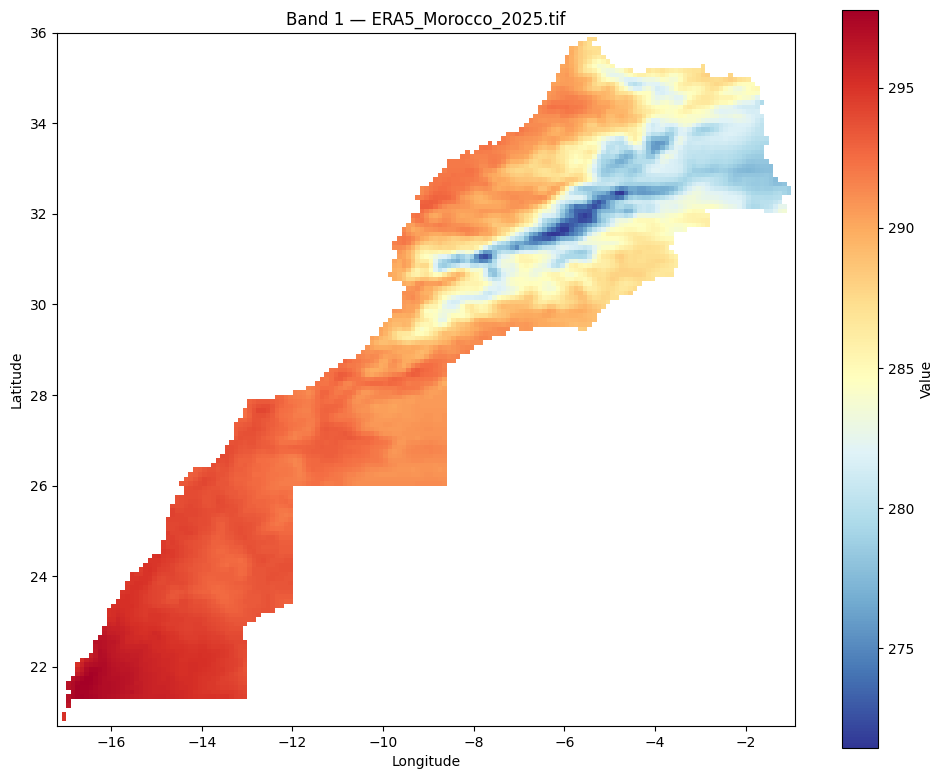

🔍 DATA QUALITY CHECK
  ⚠️  Band 1: 74.5% missing
  ⚠️  Band 2: 74.5% missing
  ⚠️  Band 3: 74.5% missing
  ⚠️  Band 4: 74.5% missing
  ⚠️  Band 5: 74.5% missing
  ⚠️  Band 6: 74.5% missing
  ⚠️  Band 7: 74.5% missing
  ⚠️  Band 8: 74.5% missing
  ⚠️  Band 9: 74.5% missing
  ⚠️  Band 10: 74.5% missing
  ⚠️  Band 11: 74.5% missing
  ⚠️  Band 12: 74.5% missing
  ⚠️  Band 13: 74.5% missing
  ⚠️  Band 14: 74.5% missing
  ⚠️  Band 15: 74.5% missing
  ⚠️  Band 16: 74.5% missing
  ⚠️  Band 17: 74.5% missing
  ⚠️  Band 18: 74.5% missing
  ⚠️  Band 19: 74.5% missing
  ⚠️  Band 20: 74.5% missing
  ⚠️  Band 21: 74.5% missing
  ⚠️  Band 22: 74.5% missing
  ⚠️  Band 23: 74.5% missing
  ⚠️  Band 24: 74.5% missing
  ⚠️  Band 25: 74.5% missing
  ⚠️  Band 26: 74.5% missing
  ⚠️  Band 27: 74.5% missing
  ⚠️  Band 28: 74.5% missing
  ⚠️  Band 29: 74.5% missing
  ⚠️  Band 30: 74.5% missing
  ⚠️  Band 31: 74.5% missing
  ⚠️  Band 32: 74.5% missing
  ⚠️  Band 33: 74.5% missing
  ⚠️  Band 34: 74.5% missing
  

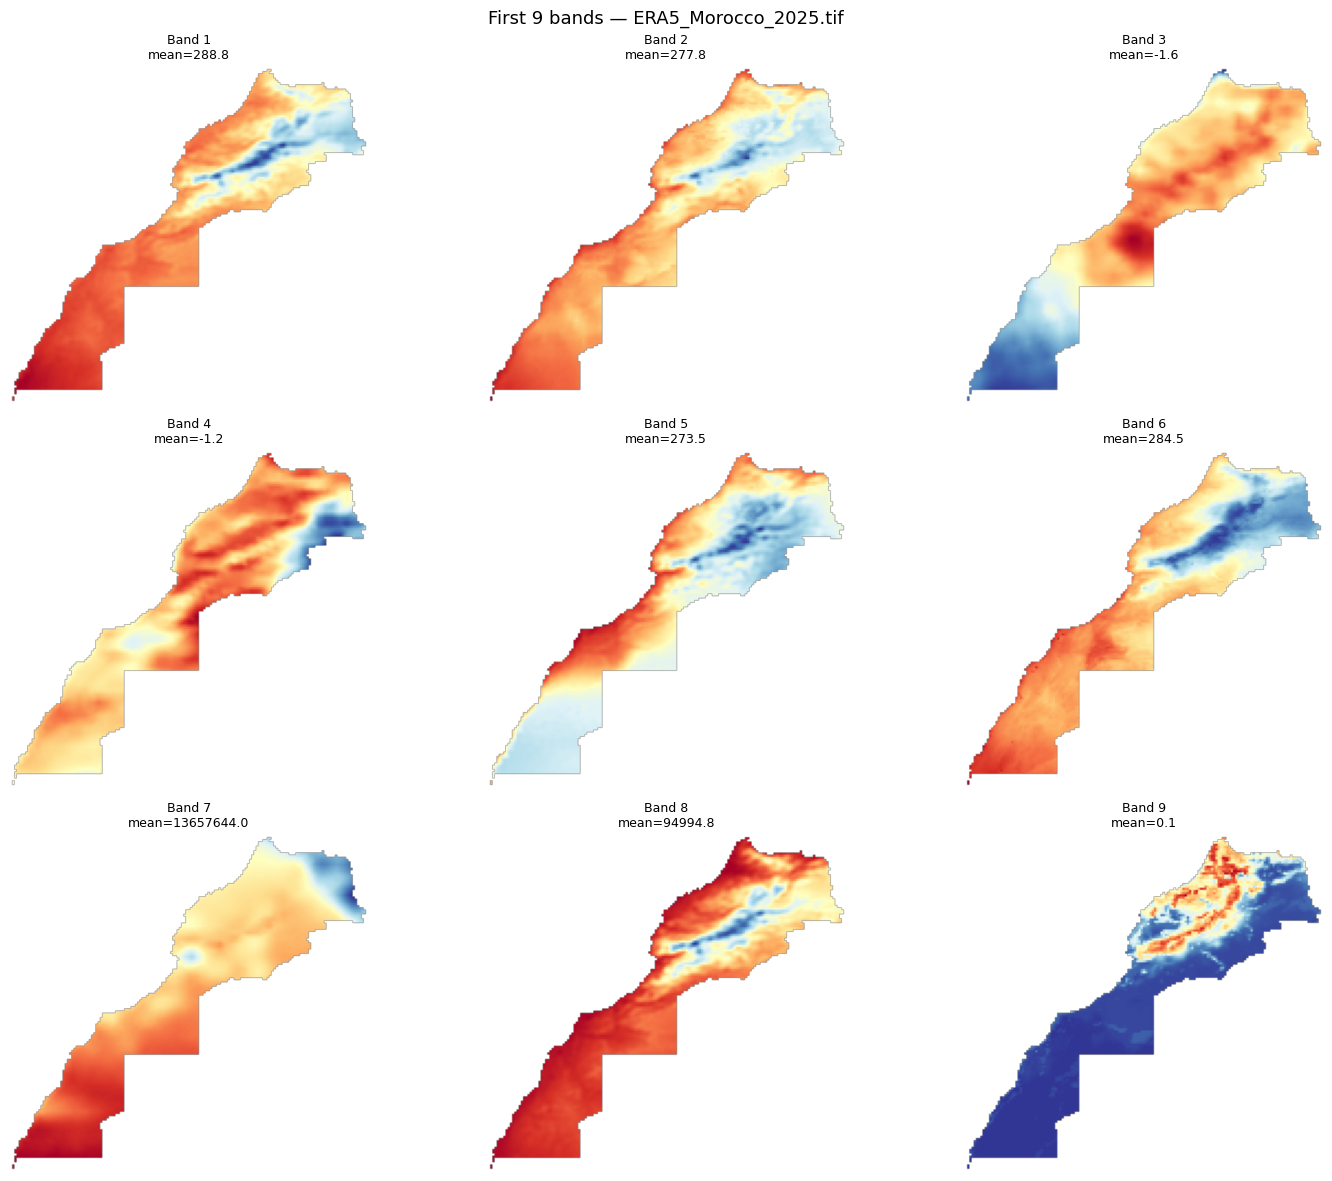

In [4]:
# ── CELL 1: Install ───────────────────────────────────────────
!pip install rasterio matplotlib numpy -q
from google.colab import drive
drive.mount('/content/drive')

TIF_PATH = '/content/drive/MyDrive/ERA5_Morocco_GeoTIFF_All1/ERA5_Morocco_2025.tif'
# adjust path to match your actual folder
import rasterio
import numpy as np

with rasterio.open(TIF_PATH) as src:
    print("=" * 50)
    print("📋 FILE METADATA")
    print("=" * 50)
    print(f"Driver        : {src.driver}")
    print(f"Width × Height: {src.width} × {src.height} pixels")
    print(f"Number of bands: {src.count}")
    print(f"Data type     : {src.dtypes[0]}")
    print(f"CRS           : {src.crs}")
    print(f"Bounds        : {src.bounds}")
    print(f"Resolution    : {src.res}")  # (x_res, y_res) in degrees
    print(f"NoData value  : {src.nodata}")
# ── CELL 4: Band names (important — check what's stacked) ─────
with rasterio.open(TIF_PATH) as src:
    print("=" * 50)
    print("📋 BAND DESCRIPTIONS")
    print("=" * 50)
    for i, desc in enumerate(src.descriptions, start=1):
        print(f"  Band {i:3d}: {desc}")

    # If descriptions are empty, check tags
    if not any(src.descriptions):
        print("\n⚠️  No band descriptions found — checking tags...")
        for i in range(1, min(src.count+1, 10)):
            print(f"  Band {i} tags: {src.tags(i)}")
# ── CELL 5: Read data + basic stats per band ───────────────────
with rasterio.open(TIF_PATH) as src:
    data = src.read()   # shape: (bands, height, width)

print(f"✅ Data shape: {data.shape}")
print(f"   = {data.shape[0]} bands × {data.shape[1]} rows × {data.shape[2]} cols")

print("\n📊 Stats per band (first 10 bands):")
for i in range(min(10, data.shape[0])):
    band = data[i]
    valid = band[~np.isnan(band)] if np.issubdtype(band.dtype, np.floating) else band
    print(f"  Band {i+1:3d}: min={valid.min():.2f}  max={valid.max():.2f}  "
          f"mean={valid.mean():.2f}  nulls={np.isnan(band).sum() if np.issubdtype(band.dtype, np.floating) else 0}")
# ── CELL 6: Visualize one band ──────────────────────────────────
import matplotlib.pyplot as plt

with rasterio.open(TIF_PATH) as src:
    band1 = src.read(1)  # first band
    bounds = src.bounds

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(
    band1,
    cmap='RdYlBu_r',
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top]
)
plt.colorbar(im, ax=ax, label='Value')
ax.set_title(f'Band 1 — {TIF_PATH.split("/")[-1]}')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()
# ── CELL 7: Check for NaN / missing data percentage ─────────────
print("=" * 50)
print("🔍 DATA QUALITY CHECK")
print("=" * 50)

n_nan_total = 0
n_total = data.size

for i in range(data.shape[0]):
    band = data[i]
    if np.issubdtype(band.dtype, np.floating):
        n_nan = np.isnan(band).sum()
    else:
        n_nan = (band == (src.nodata or -9999)).sum()
    n_nan_total += n_nan
    pct = 100 * n_nan / band.size
    if pct > 5:  # flag bands with significant missing data
        print(f"  ⚠️  Band {i+1}: {pct:.1f}% missing")

print(f"\nTotal missing: {100*n_nan_total/n_total:.2f}%")
# ── CELL 8: If bands = stacked days, check the count makes sense ─
n_bands  = data.shape[0]
n_vars   = 9   # your selected VARIABLES count
n_days_expected = n_bands / n_vars

print(f"📐 Band math check:")
print(f"   Total bands     : {n_bands}")
print(f"   Variables/day   : {n_vars}")
print(f"   Implied days    : {n_days_expected}")
print(f"   Apr–Sep ≈ 183 days expected for 1 year")

if n_days_expected != int(n_days_expected):
    print("   ⚠️  Not a clean multiple — check export logic")
# ── CELL 9: Plot grid of multiple bands (sanity check) ──────────
n_show = min(9, data.shape[0])
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i in range(n_show):
    band = data[i]
    valid = band[~np.isnan(band)] if np.issubdtype(band.dtype, np.floating) else band
    axes[i].imshow(band, cmap='RdYlBu_r')
    axes[i].set_title(f'Band {i+1}\nmean={valid.mean():.1f}', fontsize=9)
    axes[i].axis('off')

plt.suptitle(f'First {n_show} bands — {TIF_PATH.split("/")[-1]}', fontsize=13)
plt.tight_layout()
plt.show()

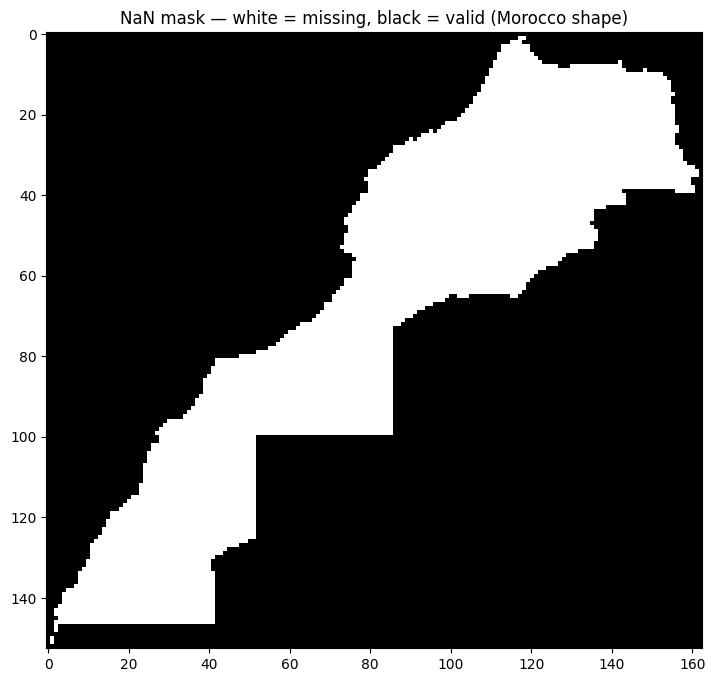

In [10]:
import matplotlib.pyplot as plt
import numpy as np

with rasterio.open(TIF_PATH) as src:
    band = src.read(1625)  # one of the flagged bands
    bounds = src.bounds

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.isnan(band)

ax.imshow(mask, cmap='gray_r')  # white = NaN, black = valid data
ax.set_title('NaN mask — white = missing, black = valid (Morocco shape)')
plt.show()

In [2]:
# ── Verify all files have the SAME grid (critical before merging) ──
import rasterio
import glob

TIF_DIR = '/content/drive/MyDrive/ERA5_Morocco_GeoTIFF_All1/'
tif_files = sorted(glob.glob(f'{TIF_DIR}*.tif'))
print(f"Found {len(tif_files)} files")

shapes = []
for f in tif_files:
    with rasterio.open(f) as src:
        shapes.append((f.split('/')[-1], src.width, src.height, src.count, src.bounds))

for name, w, h, bands, bounds in shapes:
    print(f"{name:30s} | {w}×{h} | {bands} bands | {bounds}")

# Check if all width/height match
widths  = set(s[1] for s in shapes)
heights = set(s[2] for s in shapes)
print(f"\n✅ Unique widths: {widths}")
print(f"✅ Unique heights: {heights}")
if len(widths) > 1 or len(heights) > 1:
    print("⚠️  MISMATCH — files have different grid sizes, need resampling before merge")

Found 46 files
ERA5_Morocco_1980.tif          | 163×153 | 3285 bands | BoundingBox(left=-17.20007867764784, bottom=20.70009468763432, right=-0.9000041168536654, top=36.000164674146646)
ERA5_Morocco_1981.tif          | 163×153 | 3276 bands | BoundingBox(left=-17.20007867764784, bottom=20.70009468763432, right=-0.9000041168536654, top=36.000164674146646)
ERA5_Morocco_1982.tif          | 163×153 | 3276 bands | BoundingBox(left=-17.20007867764784, bottom=20.70009468763432, right=-0.9000041168536654, top=36.000164674146646)
ERA5_Morocco_1983.tif          | 163×153 | 3276 bands | BoundingBox(left=-17.20007867764784, bottom=20.70009468763432, right=-0.9000041168536654, top=36.000164674146646)
ERA5_Morocco_1984.tif          | 163×153 | 3285 bands | BoundingBox(left=-17.20007867764784, bottom=20.70009468763432, right=-0.9000041168536654, top=36.000164674146646)
ERA5_Morocco_1985.tif          | 163×153 | 3276 bands | BoundingBox(left=-17.20007867764784, bottom=20.70009468763432, right=-0.9000041

In [3]:
# ── Merge all years directly to disk (Memory Safe) ──────────────
import numpy as np
import rasterio
import gc
import os

OUTPUT_PATH = '/content/drive/MyDrive/ERA5_Morocco_GeoTIFF_All1/ERA5_Morocco_1980_2025_MERGED.npy'

# 1. Calculate total bands first
total_bands = 0
for f in tif_files:
    with rasterio.open(f) as src:
        total_bands += src.count

# 2. Get grid dimensions and data type from the first file
with rasterio.open(tif_files[0]) as src:
    H, W = src.height, src.width
    dtype = src.dtypes[0]  # Usually float32 or float64

print(f"Grid: {H} 7 {W}")
print(f"Total bands across all years: {total_bands}")
print("Creating memory-mapped array directly on Drive...")

# 3. Create a memory-mapped array directly on disk
# This bypasses RAM and writes directly to OUTPUT_PATH
merged = np.lib.format.open_memmap(OUTPUT_PATH, mode='w+', dtype=dtype, shape=(total_bands, H, W))

band_labels = []
current_idx = 0

print(f"Merging {len(tif_files)} years chunk-by-chunk...")
for f in tif_files:
    year = f.split('_')[-1].replace('.tif', '')
    with rasterio.open(f) as src:
        count = src.count
        # Read the file and write directly into the disk-backed array
        merged[current_idx : current_idx + count] = src.read()

        for b in range(1, count + 1):
            band_labels.append(f'{year}_band{b}')

        current_idx += count

    print(f"  ✓ {year}: added {count} bands")
    # Force RAM cleanup after each year
    gc.collect()

# 4. Flush changes to disk
merged.flush()
print(f"\n✅ Successfully merged to disk without overloading RAM!")
print(f"   Final shape on disk: {merged.shape}")

Grid: 153 7 163
Total bands across all years: 150804
Creating memory-mapped array directly on Drive...
Merging 46 years chunk-by-chunk...
  ✓ 1980: added 3285 bands
  ✓ 1981: added 3276 bands
  ✓ 1982: added 3276 bands
  ✓ 1983: added 3276 bands
  ✓ 1984: added 3285 bands
  ✓ 1985: added 3276 bands
  ✓ 1986: added 3276 bands
  ✓ 1987: added 3276 bands
  ✓ 1988: added 3285 bands
  ✓ 1989: added 3276 bands
  ✓ 1990: added 3276 bands
  ✓ 1991: added 3276 bands
  ✓ 1992: added 3285 bands
  ✓ 1993: added 3276 bands
  ✓ 1994: added 3276 bands
  ✓ 1995: added 3276 bands
  ✓ 1996: added 3285 bands
  ✓ 1997: added 3276 bands
  ✓ 1998: added 3276 bands
  ✓ 1999: added 3276 bands
  ✓ 2000: added 3285 bands
  ✓ 2001: added 3276 bands
  ✓ 2002: added 3276 bands
  ✓ 2003: added 3276 bands
  ✓ 2004: added 3285 bands
  ✓ 2005: added 3276 bands
  ✓ 2006: added 3276 bands
  ✓ 2007: added 3276 bands
  ✓ 2008: added 3285 bands
  ✓ 2009: added 3276 bands
  ✓ 2010: added 3276 bands
  ✓ 2011: added 3276 band

In [4]:
# ── Save labels (Array is already saved via memmap) ─────────────────────
import json

OUTPUT_PATH = '/content/drive/MyDrive/ERA5_Morocco_GeoTIFF_All1/ERA5_Morocco_1980_2025_MERGED.npy'

# The .npy file was already saved directly to disk in the previous cell.
# We only need to save the band labels separately so you know what each slice is.
with open(OUTPUT_PATH.replace('.npy', '_labels.json'), 'w') as f:
    json.dump(band_labels, f)

print(f"✅ Array is ready at: {OUTPUT_PATH}")
print(f"✅ Saved labels: {OUTPUT_PATH.replace('.npy', '_labels.json')}")

✅ Array is ready at: /content/drive/MyDrive/ERA5_Morocco_GeoTIFF_All1/ERA5_Morocco_1980_2025_MERGED.npy
✅ Saved labels: /content/drive/MyDrive/ERA5_Morocco_GeoTIFF_All1/ERA5_Morocco_1980_2025_MERGED_labels.json


### 1. Reshape & Preview the Data
Because we have 9 variables per day, we can reshape the `(73710, 153, 163)` array into a 4D array of `(days, 9, 153, 163)`. This gives us a much easier way to slice the data!

Reshaping data into 16756 days...
New shape: (16756, 9, 153, 163) -> (Days, Variables, Height, Width)


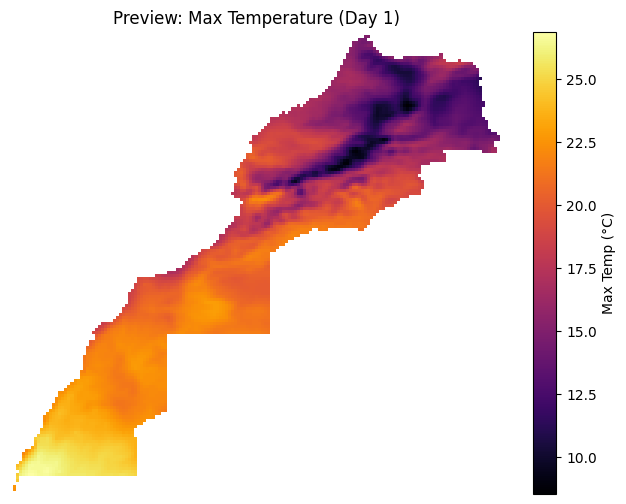

In [5]:
import matplotlib.pyplot as plt

# There are 9 variables downloaded per day
n_vars = 9
n_days = merged.shape[0] // n_vars

print(f"Reshaping data into {n_days} days...")
# Reshape into (days, variables, H, W).
# This is a 'view', so it takes almost ZERO extra RAM!
daily_data = merged.reshape((n_days, n_vars, merged.shape[1], merged.shape[2]))

print(f"New shape: {daily_data.shape} -> (Days, Variables, Height, Width)")

# Let's preview Day 0, Variable 0 (Max Temp)
plt.figure(figsize=(8,6))
# Index 0 is temperature_2m_max (in Kelvin). Subtract 273.15 for Celsius
tmax_c = daily_data[0, 0, :, :] - 273.15

plt.imshow(tmax_c, cmap='inferno')
plt.colorbar(label='Max Temp (°C)')
plt.title('Preview: Max Temperature (Day 1)')
plt.axis('off')
plt.show()


In [ ]:
import seaborn as sns
import pandas as pd

# Take a 1-year sample to prevent RAM overflow
sample_days = min(182, daily_data.shape[0])
print(f"Extracting data for {sample_days} days...")

# Transpose to (Variables, Days, H, W) and then flatten to (Variables, Pixels)
# daily_data shape is (days, vars, H, W)
flat_data = daily_data[:sample_days].transpose(1, 0, 2, 3).reshape(n_vars, -1)

# Mask out the NaNs (ocean and areas outside Morocco)
valid_mask = ~np.isnan(flat_data).any(axis=0)
clean_data = flat_data[:, valid_mask]

# Variable names for the plot
var_names = [
    'Max Temp',
    'Min Temp',
    'U Wind',
    'V Wind',
    'Dewpoint',
    'Soil Temp',
    'Solar Rad',
    'Surface Press',
    'Soil Moisture'
]

print(f"Calculating correlation on {clean_data.shape[1]:,} valid pixel-days...")

# Compute the correlation matrix
corr_matrix = np.corrcoef(clean_data)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    xticklabels=var_names,
    yticklabels=var_names,
    vmin=-1,
    vmax=1
)
plt.title('Weather Variables Correlation Heatmap (1-Year Sample)')
plt.tight_layout()
plt.show()


### 4. Correlation Heatmap (Full 1980-2025 Dataset)
By extracting only the valid land pixels first, we drastically reduce memory usage, allowing us to compute the correlation matrix over the entire 45-year dataset.

### Save Data & Labels Together as .npz
This bundles everything into one neat file instead of separate `.npy` and `.json` files.

In [7]:
NPZ_PATH = '/content/drive/MyDrive/ERA5_Morocco_GeoTIFF_All1/ERA5_Morocco_1980_2025_MERGED.npz'

print("Saving array and labels to a single .npz file...")
# np.savez bundles multiple variables using keyword arguments
np.savez(NPZ_PATH, data=merged, labels=band_labels)

print(f"✅ Saved everything into one file: {NPZ_PATH}")

# --- How to load it later ---
# loaded = np.load(NPZ_PATH)
# my_data = loaded['data']
# my_labels = loaded['labels']


Saving array and labels to a single .npz file...
✅ Saved everything into one file: /content/drive/MyDrive/ERA5_Morocco_GeoTIFF_All1/ERA5_Morocco_1980_2025_MERGED.npz


### 5. Calculations on the Data
Here is how you will load your `.npz` file in future sessions to perform calculations. For now, we will use the `daily_data` already in RAM to calculate the 45-year average.

In [1]:
import numpy as np
from google.colab import drive

# Ensure Drive is mounted
drive.mount('/content/drive')

NPY_PATH = '/content/drive/MyDrive/ERA5_Morocco_GeoTIFF_All1/ERA5_Morocco_1980_2025_MERGED.npy'
print(f"\nLoading fast .npy dataset from {NPY_PATH} (Memory-Mapped)...")

# Load the raw numpy array directly using mmap_mode to save RAM
raw_data = np.load(NPY_PATH, mmap_mode='r')

n_vars = 9
n_days = raw_data.shape[0] // n_vars

# 1. Reshape to (days, vars, H, W)
daily_data = raw_data.reshape((n_days, n_vars, raw_data.shape[1], raw_data.shape[2]))

# 2. Transpose to (days, H, W, vars) for Machine Learning
full_data = daily_data.transpose(0, 2, 3, 1)

print(f"\n✅ Full dataset ready as a memory-mapped view: {full_data.shape}")
print(f"   (total_days, H, W, n_vars)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Loading fast .npy dataset from /content/drive/MyDrive/ERA5_Morocco_GeoTIFF_All1/ERA5_Morocco_1980_2025_MERGED.npy (Memory-Mapped)...

✅ Full dataset ready as a memory-mapped view: (16756, 153, 163, 9)
   (total_days, H, W, n_vars)


In [2]:
# ── CELL 2: Fill NaN (ocean/outside Morocco) with 0 in BATCHES ────────────
import numpy as np
import os
from tqdm import tqdm
import gc

CLEAN_NPY_PATH = '/content/drive/MyDrive/ERA5_Morocco_GeoTIFF_All1/ERA5_Morocco_CLEAN_float32.npy'
print("Creating a memory-mapped array for the cleaned data to save RAM...")

# Create a new memory-mapped array for the float32 data
full_data_clean = np.lib.format.open_memmap(
    CLEAN_NPY_PATH,
    mode='w+',
    dtype=np.float32,
    shape=full_data.shape
)

BATCH_SIZE = 100
for i in tqdm(range(0, full_data.shape[0], BATCH_SIZE), desc="Filling NaNs"):
    batch = full_data[i:i+BATCH_SIZE]
    # Fill NaNs and convert to float32 on the small batch only
    batch_clean = np.nan_to_num(batch, nan=0.0).astype(np.float32)
    full_data_clean[i:i+BATCH_SIZE] = batch_clean

    del batch, batch_clean
    gc.collect()

full_data_clean.flush()

# Replace the reference in memory so the rest of the notebook uses the clean array
full_data = full_data_clean

print(f"\n✅ NaN filled safely in batches! Data is now float32.")
print(f"   Shape: {full_data.shape}")

Creating a memory-mapped array for the cleaned data to save RAM...


Filling NaNs: 100%|██████████| 168/168 [08:32<00:00,  3.05s/it]


✅ NaN filled safely in batches! Data is now float32.
   Shape: (16756, 153, 163, 9)


In [3]:
# ── CELL 3: Save as compressed NPZ ─────────────────────────────
import os

# Create directory if it doesn't exist
os.makedirs('/content/drive/MyDrive/ERA5_Morocco_ConvLSTM_1', exist_ok=True)

# Extract grid dimensions
H, W = full_data.shape[1], full_data.shape[2]

# Recreate the valid land mask from the original daily_data (before NaNs were filled with 0)
valid_mask = ~np.isnan(daily_data[0, 0, :, :])

np.savez_compressed(
    '/content/drive/MyDrive/ERA5_Morocco_ConvLSTM_1/era5_full_grid_1980_2025.npz',
    data=full_data,
    valid_mask=valid_mask,   # save mask too — useful for loss masking
    height=H,
    width=W
)
print("✅ Saved as .npz — ready for ConvLSTM")


✅ Saved as .npz — ready for ConvLSTM


### 6. Calculate & Append Derived Features
We will calculate Wind Speed, Relative Humidity, Heat Index, and Wind Chill batch-by-batch to save RAM, and then append them to `full_data`.

In [4]:
import numpy as np
import gc
from tqdm import tqdm

print("Calculating derived features in batches to save RAM...")

n_days, H, W, n_vars = full_data.shape
# Pre-allocate array for 4 new features: Wind Speed, RH, Heat Index, Wind Chill
extra_features = np.zeros((n_days, H, W, 4), dtype=np.float32)

BATCH_SIZE = 100

for start_idx in tqdm(range(0, n_days, BATCH_SIZE), desc="Processing Batches"):
    end_idx = min(start_idx + BATCH_SIZE, n_days)

    # Slice current batch
    batch = full_data[start_idx:end_idx]

    # 0: Tmax(K), 1: Tmin(K), 2: u_wind, 3: v_wind, 4: Tdew(K)
    Tmax_k = batch[..., 0]
    Tmin_k = batch[..., 1]
    u      = batch[..., 2]
    v      = batch[..., 3]
    Tdew_k = batch[..., 4]

    # Identify valid pixels to avoid calculating on empty/ocean cells (which are exactly 0.0 now)
    valid = (Tmax_k > 0)

    Tmax_c  = np.where(valid, Tmax_k - 273.15, 0)
    Tmin_c  = np.where(valid, Tmin_k - 273.15, 0)
    Tmean_c = (Tmax_c + Tmin_c) / 2
    Tdew_c  = np.where(valid, Tdew_k - 273.15, 0)

    # ─── 1. WIND SPEED (m/s) ───
    wind_speed = np.sqrt(u**2 + v**2)
    wind_speed = np.where(valid, wind_speed, 0)

    # ─── 2. RELATIVE HUMIDITY (%) ───
    e_actual = 6.112 * np.exp((17.67 * Tdew_c) / (Tdew_c + 243.5))
    e_sat    = 6.112 * np.exp((17.67 * Tmean_c) / (Tmean_c + 243.5))
    rh = np.where((valid) & (e_sat > 0), (e_actual / e_sat) * 100, 0)
    rh = np.clip(rh, 0, 100) # Cap at 100%

    # ─── 3. HEAT INDEX (°C) ───
    # Standard Rothfusz formula uses Fahrenheit (based on Tmax)
    Tf = Tmax_c * 1.8 + 32

    # Simplified formula
    hi_f = 0.5 * (Tf + 61.0 + ((Tf - 68.0) * 1.2) + (rh * 0.094))

    # Full formula for Tf >= 80
    hi_full = (-42.379 + 2.04901523*Tf + 10.14333127*rh - 0.22475541*Tf*rh
               - 0.00683783*Tf**2 - 0.05481717*rh**2 + 0.00122874*Tf**2*rh
               + 0.00085282*Tf*rh**2 - 0.00000199*Tf**2*rh**2)

    hi_f = np.where(Tf >= 80, hi_full, hi_f)
    hi_c = np.where(valid, (hi_f - 32) / 1.8, 0) # Convert back to Celsius

    # ─── 4. WIND CHILL (°C) ───
    # Using Tmin for Wind Chill to capture the coldest feel of the day
    Tf_min = Tmin_c * 1.8 + 32
    v_mph = wind_speed * 2.23694
    wc_f = 35.74 + 0.6215*Tf_min - 35.75*(v_mph**0.16) + 0.4275*Tf_min*(v_mph**0.16)
    # Removing the strict <= 50 F threshold so the formula takes effect for all temperatures (as long as there is wind > 3 mph)
    wc_f = np.where(v_mph > 3, wc_f, Tf_min)
    wc_c = np.where(valid, (wc_f - 32) / 1.8, 0)

    # Assign to array
    extra_features[start_idx:end_idx, ..., 0] = wind_speed
    extra_features[start_idx:end_idx, ..., 1] = rh
    extra_features[start_idx:end_idx, ..., 2] = hi_c
    extra_features[start_idx:end_idx, ..., 3] = wc_c

print("\n✅ Batch calculations complete.")

# Ensure we do not continuously append if the cell is run multiple times
if full_data.shape[-1] >= 13:
    full_data = full_data[..., :9]

# Concatenate along the variables axis (axis=-1)
full_data = np.concatenate([full_data, extra_features], axis=-1)

print(f"✅ New `full_data` shape: {full_data.shape}")
print(f"   Features are now: [Max T, Min T, U, V, Tdew, Soil T, Solar, Press, Soil M, WindSpeed, RH, HeatIndex, WindChill]")

# Clean up temporary arrays to free RAM
del extra_features
gc.collect()


Calculating derived features in batches to save RAM...


Processing Batches: 100%|██████████| 168/168 [00:54<00:00,  3.09it/s]



✅ Batch calculations complete.
✅ New `full_data` shape: (16756, 153, 163, 13)
   Features are now: [Max T, Min T, U, V, Tdew, Soil T, Solar, Press, Soil M, WindSpeed, RH, HeatIndex, WindChill]


0

In [5]:
# ── Re-save the final NPZ file with the new features ───────────────────
print("Updating the compressed .npz file with 13 features...")

np.savez_compressed(
    '/content/drive/MyDrive/ERA5_Morocco_ConvLSTM_1/era5_full_grid_1980_2025_13features.npz',
    data=full_data,
    valid_mask=valid_mask,
    height=H,
    width=W
)
print("✅ Updated .npz successfully saved!")

Updating the compressed .npz file with 13 features...
✅ Updated .npz successfully saved!


### 7. Updated Correlation Heatmap (13 Features)
Let's visualize the correlation matrix of the newly updated dataset containing 13 features to ensure our calculations make sense.

Extracting full 45-year dataset for correlation (13 features)...
Calculating correlation on 106,400,600 valid pixel-days...


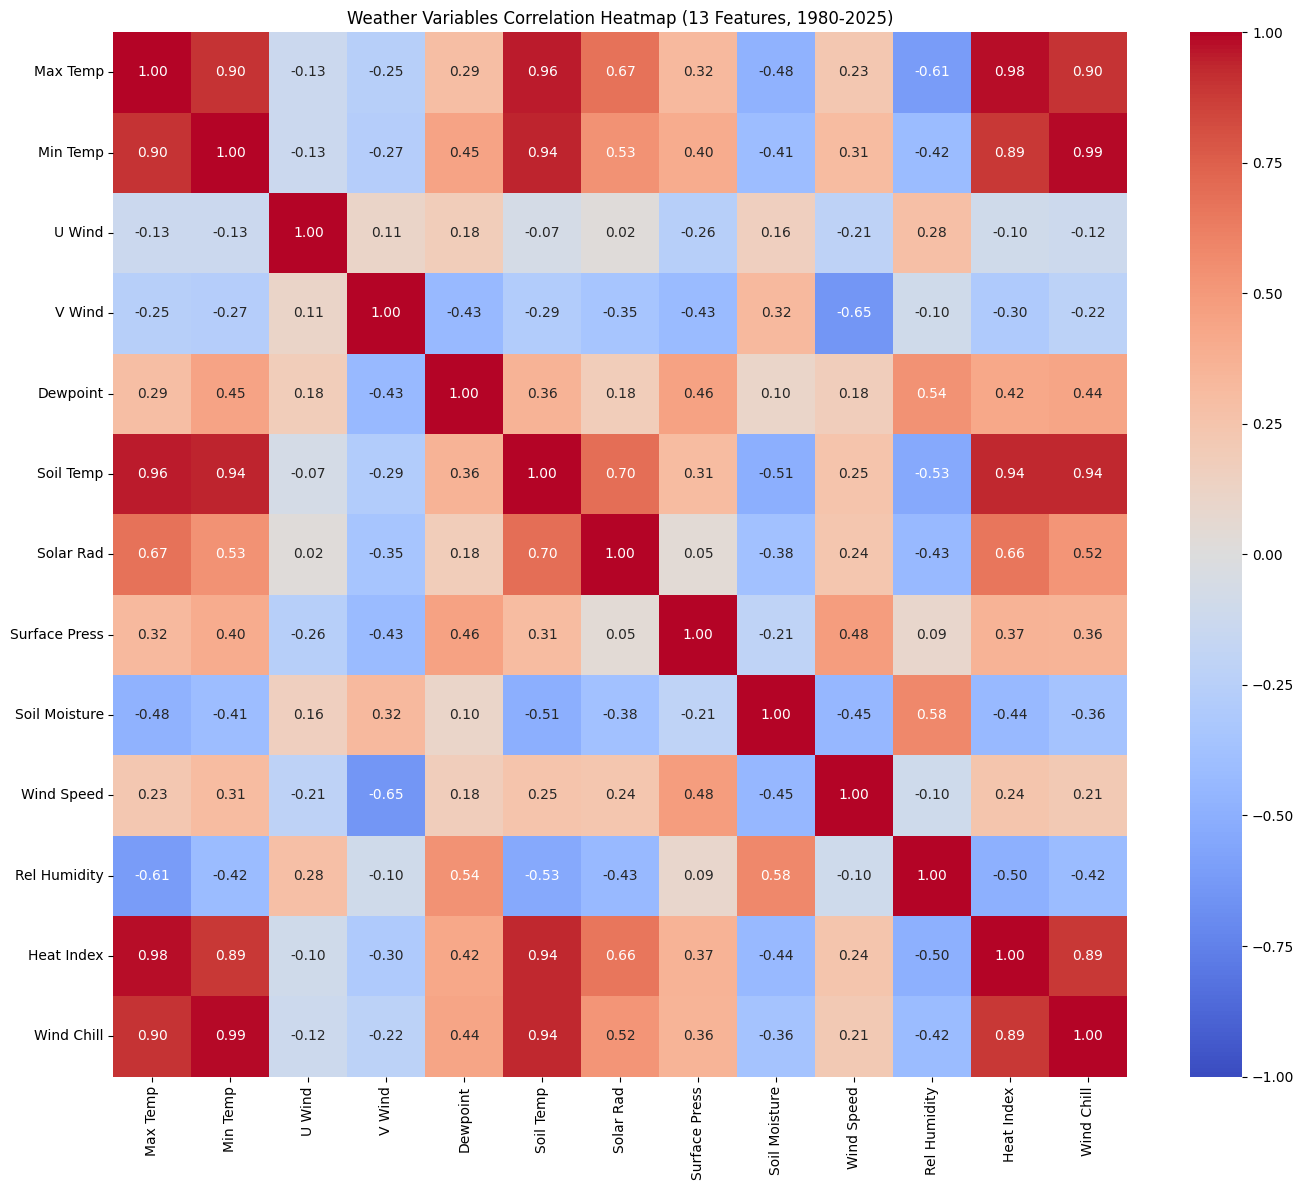

15829

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import gc

print("Extracting full 45-year dataset for correlation (13 features)...")

# Extract only valid land pixels to save memory
# full_data shape: (days, H, W, vars), valid_mask shape: (H, W)
# Slicing gives (days, valid_pixels, vars)
land_data = full_data[:, valid_mask, :]

# Transpose to (vars, days, valid_pixels) and flatten the last two dimensions
# Shape becomes: (13, days * valid_pixels)
clean_data = land_data.transpose(2, 0, 1).reshape(13, -1)

# Free up memory
del land_data
gc.collect()

print(f"Calculating correlation on {clean_data.shape[1]:,} valid pixel-days...")

# Compute the correlation matrix
corr_matrix = np.corrcoef(clean_data)

# Updated variable names
var_names = [
    'Max Temp', 'Min Temp', 'U Wind', 'V Wind',
    'Dewpoint', 'Soil Temp', 'Solar Rad',
    'Surface Press', 'Soil Moisture',
    'Wind Speed', 'Rel Humidity', 'Heat Index', 'Wind Chill'
]

# Plot the heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    xticklabels=var_names,
    yticklabels=var_names,
    vmin=-1,
    vmax=1
)
plt.title('Weather Variables Correlation Heatmap (13 Features, 1980-2025)')
plt.tight_layout()
plt.show()

# Clean up massive array after plotting
del clean_data
gc.collect()


In [22]:
# ── Montage Google Drive ──
from google.colab import drive
import os

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

import sys, json, csv, logging
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')

import torch
import torch.nn as nn
import torch.nn.functional as F

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s | %(levelname)-8s | %(message)s')
log = logging.getLogger('Benchmark')

print(f'PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision('high')
print(f'Device: {DEVICE}')

PyTorch 2.11.0+cu128  |  CUDA: True
Device: cuda


In [27]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Sequence
import logging

# ── Configuration Adapted for .npz ──
@dataclass
class BenchmarkConfig:
    data_path:       str = '/content/drive/MyDrive/ERA5_Morocco_ConvLSTM_1/era5_full_grid_1980_2025_13features.npz'
    output_dir:      str = '/content/drive/MyDrive/training_artifacts_npz'
    input_window:    int = 7
    output_window:   int = 7
    train_ratio:    float = 0.70
    val_ratio:      float = 0.15
    test_ratio:     float = 0.15
    batch_size:      int = 8
    epochs:          int = 80
    learning_rate:  float = 5e-4
    filters:         int = 64
    predrnn_hidden:  int = 64
    tf_ratio_start: float = 0.5
    use_amp:        bool = False
    seed:            int = 42

    # 13 features from the .npz array (in the exact order they were concatenated)
    channels:        Sequence[str] = (
        'Tmax', 'Tmin', 'u_wind', 'v_wind', 'Tdew', 'SoilT',
        'Solar', 'Press', 'SoilM', 'WindSpeed', 'RH', 'HeatIndex', 'WindChill'
    )

    # The targets we want to predict
    targets:         Sequence[str] = ('HeatIndex', 'WindChill')

    def __post_init__(self):
        self.n_in = len(self.channels)
        self.n_out = len(self.targets)

        # Map target names to their integer indices in the channel list
        self.target_indices = [self.channels.index(t) for t in self.targets]

cfg = BenchmarkConfig()
OUTPUT_DIR = Path(cfg.output_dir)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Input:  {cfg.input_window} days × {cfg.n_in} channels')
print(f'Output: {cfg.output_window} days × {cfg.n_out} targets {cfg.targets}')
print(f'Batch:  {cfg.batch_size}  |  Epochs: {cfg.epochs}  |  Filters: {cfg.filters}')

Input:  7 days × 13 channels
Output: 7 days × 2 targets ('HeatIndex', 'WindChill')
Batch:  8  |  Epochs: 80  |  Filters: 64


In [24]:
# ── Dataset Class for .npz files ──
class NPZClimateDataset(Dataset):
    def __init__(self, config: BenchmarkConfig, split: str = 'train'):
        super().__init__()
        self.cfg = config
        self.split = split

        print(f"Loading data for {split} split from {config.data_path}...")
        # Load the .npz file
        loaded = np.load(config.data_path)
        self.data = loaded['data']  # Raw shape: (days, H, W, vars)
        self.valid_mask = loaded['valid_mask'] # Shape: (H, W)

        # Transpose to (days, vars, H, W) for PyTorch Conv2D/ConvLSTM compatibility
        self.data = self.data.transpose(0, 3, 1, 2)

        total_days = self.data.shape[0]

        # Calculate splits
        train_end = int(total_days * config.train_ratio)
        val_end = train_end + int(total_days * config.val_ratio)

        if split == 'train':
            self.split_data = self.data[:train_end]
        elif split == 'val':
            self.split_data = self.data[train_end:val_end]
        elif split == 'test':
            self.split_data = self.data[val_end:]
        else:
            raise ValueError("split must be 'train', 'val', or 'test'")

        self.seq_len = config.input_window + config.output_window
        self.n_samples = len(self.split_data) - self.seq_len + 1

        print(f"✅ {split.capitalize()} dataset ready: {self.n_samples} sequences.")

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        # Extract the sequence window (Input + Output days)
        window = self.split_data[idx : idx + self.seq_len]

        # Input: first `input_window` days, ALL 13 channels
        X = window[:self.cfg.input_window]

        # Target: next `output_window` days, ONLY target channels (HeatIndex, WindChill)
        Y = window[self.cfg.input_window:, self.cfg.target_indices]

        # Convert to PyTorch tensors
        return torch.tensor(X, dtype=torch.float32), torch.tensor(Y, dtype=torch.float32)

# ── Test the Dataset & DataLoader ──
train_ds = NPZClimateDataset(cfg, split='train')
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)

X_batch, Y_batch = next(iter(train_loader))
print(f"\n🔍 Batch shapes check:")
print(f"X_batch shape: {X_batch.shape} -> (batch, in_seq, channels, H, W)")
print(f"Y_batch shape: {Y_batch.shape} -> (batch, out_seq, target_channels, H, W)")

Loading data for train split from /content/drive/MyDrive/ERA5_Morocco_ConvLSTM_1/era5_full_grid_1980_2025_13features.npz...


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/ERA5_Morocco_ConvLSTM_1/era5_full_grid_1980_2025_13features.npz'

In [25]:
import os
import json

file_name = "train_benchmark_models_v2.ipynb"
search_dir = "/content/drive/MyDrive/"
found_path = None

print(f"Searching for {file_name} in {search_dir}...")
for root, dirs, files in os.walk(search_dir):
    if file_name in files:
        found_path = os.path.join(root, file_name)
        break

if found_path:
    print(f"\u2705 Found at: {found_path}\n")
    with open(found_path, 'r', encoding='utf-8') as f:
        nb = json.load(f)
        code_cells = [c for c in nb.get("cells", []) if c.get("cell_type") == "code"]

        print("Extracting Model and Training Loop cells:\n" + "="*50)
        for i, cell in enumerate(code_cells):
            source = "".join(cell.get("source", []))
            # Look for keywords that indicate model definition or training loop
            if "class " in source or "def train" in source or "nn.Module" in source or "optimizer" in source:
                print(f"# ── Original Cell {i} ──")
                print(source)
                print("\n" + "="*50 + "\n")
else:
    print(f"\u274c {file_name} not found in {search_dir}.")

Searching for train_benchmark_models_v2.ipynb in /content/drive/MyDrive/...
❌ train_benchmark_models_v2.ipynb not found in /content/drive/MyDrive/.


In [26]:
import os

# Check the dataset folder
data_dir = '/content/drive/MyDrive/ERA5_Morocco_ConvLSTM_1'
print(f"Files in {data_dir}:")
if os.path.exists(data_dir):
    for f in os.listdir(data_dir):
        print(f" - {f}")
else:
    print("Directory does not exist!")

print("\n" + "="*50 + "\n")

# Search for the benchmark notebook with partial name matching
search_dir = "/content/drive/MyDrive/"
print("Searching for notebooks containing 'benchmark' or 'train'... ")
for root, dirs, files in os.walk(search_dir):
    for file in files:
        if "benchmark" in file.lower() or "train" in file.lower():
            if file.endswith(".ipynb"):
                print(os.path.join(root, file))

Files in /content/drive/MyDrive/ERA5_Morocco_ConvLSTM_1:
Directory does not exist!


Searching for notebooks containing 'benchmark' or 'train'... 
